# 1. Data Loading

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_handling import DataHandler

In [12]:
# load datasets
amazon_file = '../data/raw/amazon_books_ratings.csv'
sentiment140_file = '../data/raw/sentiment140.csv'
yelp_file = '../data/raw/yelp_reviews.csv'

# read datasets
amazon_df = pd.read_csv(amazon_file, engine='python', names=["Polarity", "Review"], skiprows=1, usecols=[6, 8], encoding="ISO-8859-1")
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', names=["Polarity", "Review"], usecols=[0, 5], encoding="ISO-8859-1")
yelp_df = pd.read_csv(yelp_file, engine='python', names=["Polarity", "Review"], encoding="ISO-8859-1")

In [13]:
# inspect dataframes
print("Amazon Books Reviews DataFrame:")
print(amazon_df.head())
print("\nSentiment140 DataFrame:")
print(sentiment140_df.head())
print("\nYelp Reviews DataFrame:")
print(yelp_df.head())

Amazon Books Reviews DataFrame:
   Polarity                                           Review
0       4.0           Nice collection of Julie Strain images
1       5.0                                Really Enjoyed It
2       5.0  Essential for every personal and Public Library
3       4.0  Phlip Nel gives silly Seuss a serious treatment
4       4.0                           Good academic overview

Sentiment140 DataFrame:
   Polarity                                             Review
0         0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1         0  is upset that he can't update his Facebook by ...
2         0  @Kenichan I dived many times for the ball. Man...
3         0    my whole body feels itchy and like its on fire 
4         0  @nationwideclass no, it's not behaving at all....

Yelp Reviews DataFrame:
   Polarity                                             Review
0         1  Unfortunately, the frustration of being Dr. Go...
1         2  Been going to Dr. Goldberg for over

# 2. Data Analysis

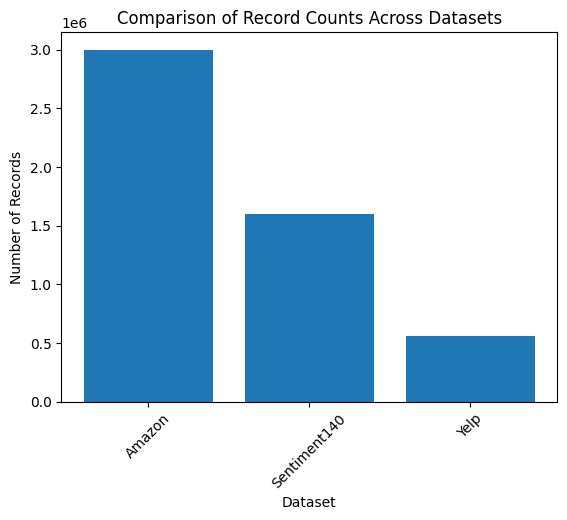

In [14]:
# plot chart showing the number of records per dataset
data = {'Dataset': ['Amazon', 'Sentiment140', 'Yelp'], 'Number of Records': [len(amazon_df), len(sentiment140_df), len(yelp_df)]}

df = pd.DataFrame(data)

plt.bar(df['Dataset'], df['Number of Records'])
plt.xlabel('Dataset') 
plt.ylabel('Number of Records')
plt.title('Comparison of Record Counts Across Datasets')
plt.xticks(rotation=45) 
plt.show()

In [15]:
# list of dataframes and their names
dfs = [amazon_df, sentiment140_df, yelp_df]
dataset_names = ['Amazon', 'Sentiment140', 'Yelp']

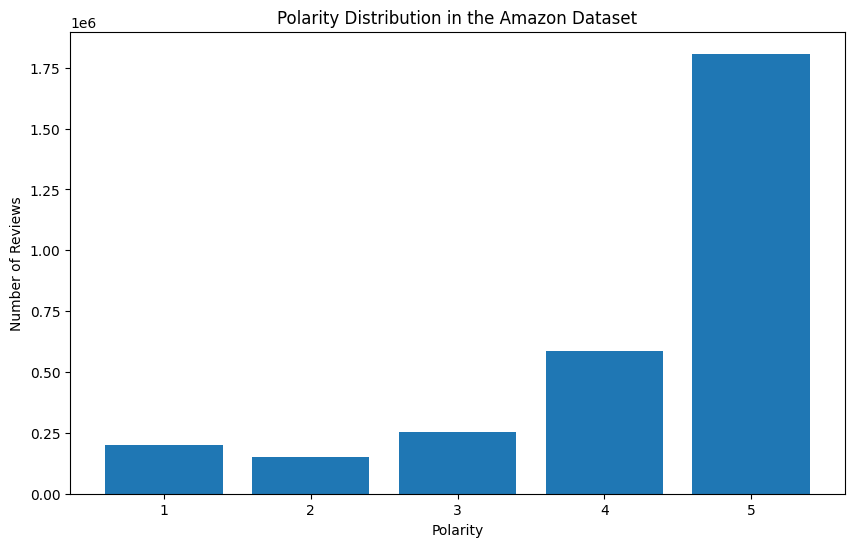

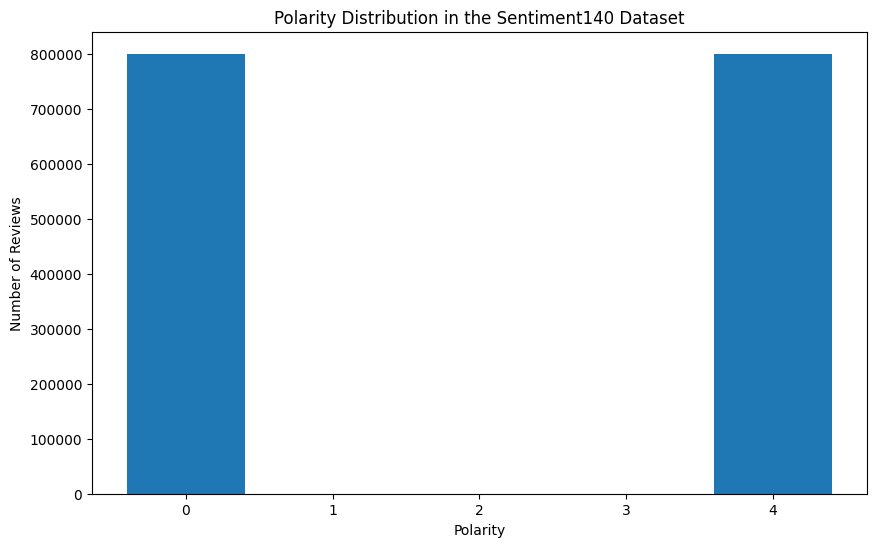

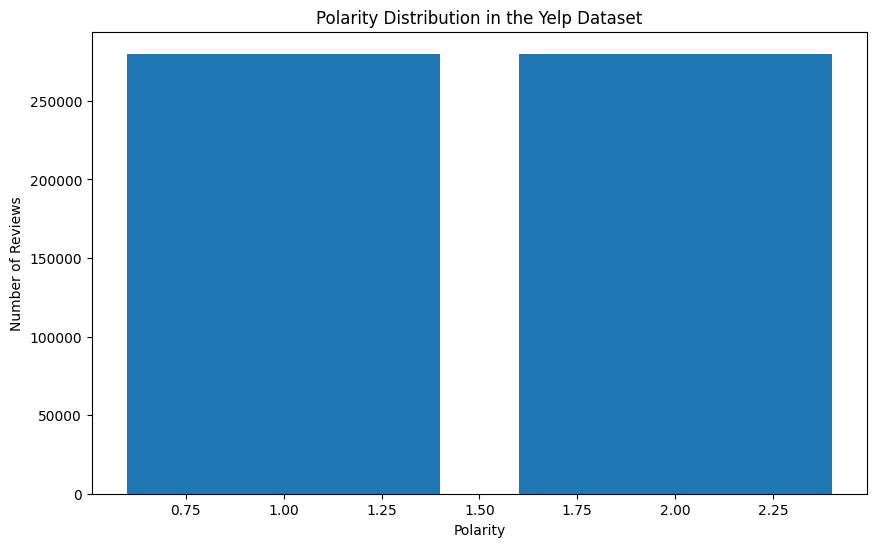

In [16]:
# plot distribution of review polarity across datasets
for df, name in zip(dfs, dataset_names):
    DataHandler.plot_polarity_distribution(df, name)

In [17]:
import nltk

# download the tokenizer for sentence and word tokenization
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

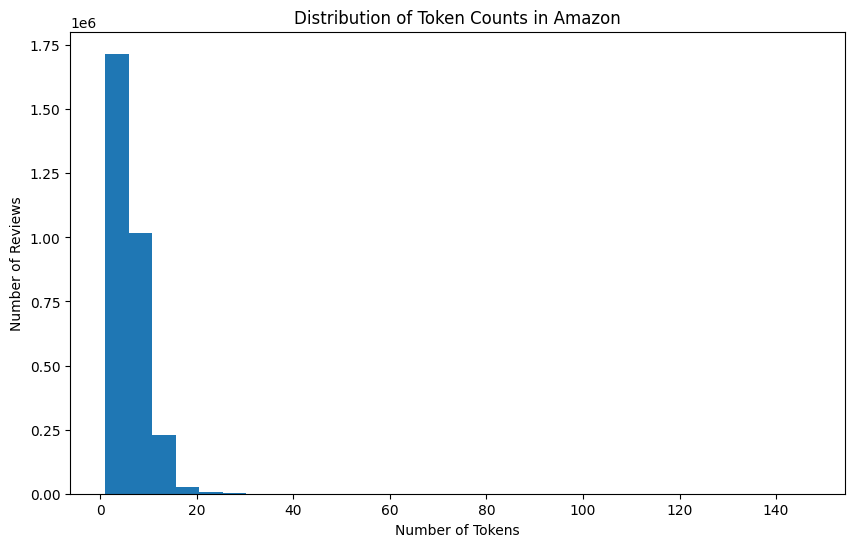

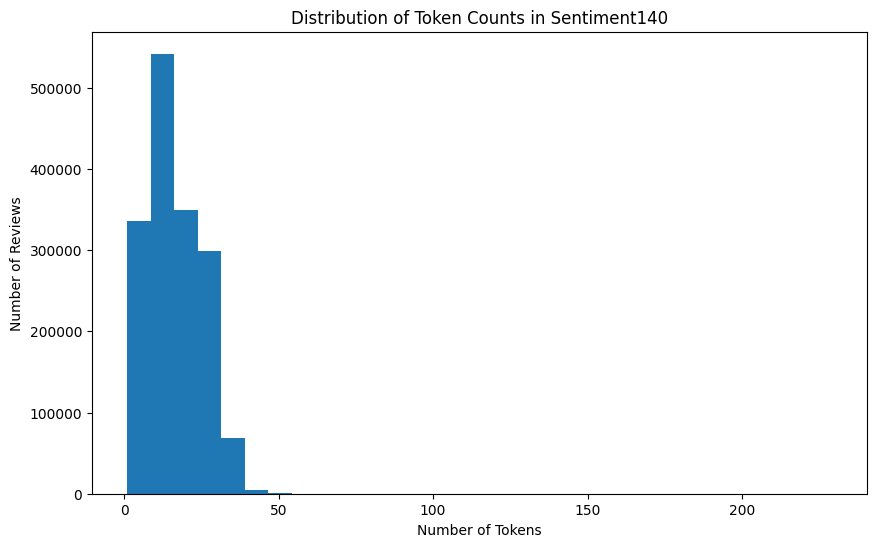

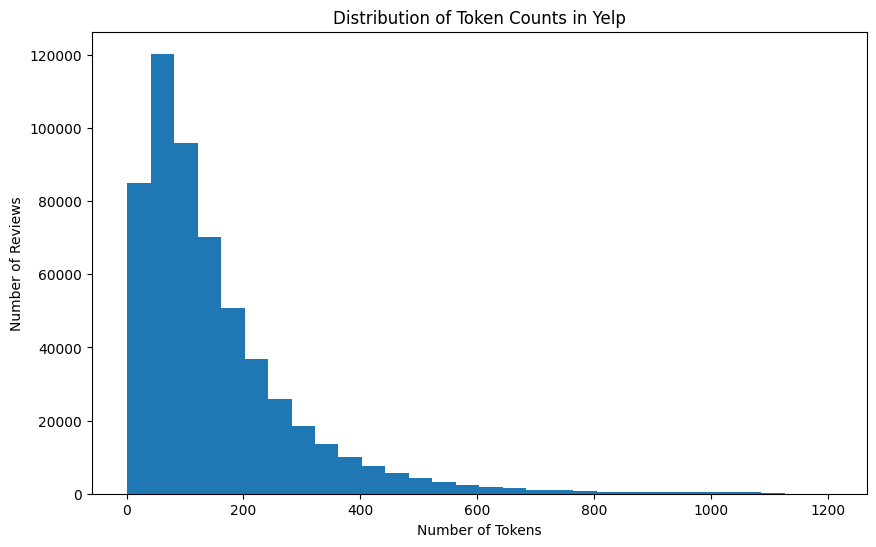

In [18]:
# plot the distribution of token counts across datasets by polarity
for df, name in zip(dfs, dataset_names):
    DataHandler.plot_token_distribution(df, name)

# 3. General Data Preprocessing

In [19]:
# remove rows containing NaN in any column
for df in dfs:
    df.dropna(inplace=True)

## 3.1 Data Preprocessing - Amazon Books Ratings

In [20]:
# standardize the dataset
# count the number of records for each class
count_1 = len(amazon_df[amazon_df['Polarity'] == 1.0])
count_2 = len(amazon_df[amazon_df['Polarity'] == 2.0])
count_4 = len(amazon_df[amazon_df['Polarity'] == 4.0])
count_5 = len(amazon_df[amazon_df['Polarity'] == 5.0])

count_1_and_2 = count_1 + count_2

# calculate the number of records to keep for class 5.0
factor_5 = count_5 / (count_5 + count_4)
num_records_5 = int(round(factor_5 * count_1_and_2))

# calculate the number of records to keep for class 4.0
num_records_4 = (count_1 + count_2) - num_records_5

# select records from class 5.0
class_5_sampled = amazon_df[amazon_df['Polarity'] == 5.0].sample(n=num_records_5, random_state=42)

# select records from class 4.0
class_4_sampled = amazon_df[amazon_df['Polarity'] == 4.0].sample(n=num_records_4, random_state=42)

# select all records from classes 1.0 and 2.0
class_1_all = amazon_df[amazon_df['Polarity'] == 1.0]
class_2_all = amazon_df[amazon_df['Polarity'] == 2.0]

# remove records with class 3.0
amazon_df = amazon_df[amazon_df['Polarity'] != 3.0]

# combine the selected records into a single DataFrame
amazon_balanced_df = pd.concat([class_5_sampled, class_4_sampled, class_1_all, class_2_all])

# reset the index in the final DataFrame
amazon_balanced_df.reset_index(drop=True, inplace=True)

# display a summary of the polarity distribution
print(amazon_balanced_df['Polarity'].value_counts())


Polarity
5.0    266372
1.0    201650
2.0    151033
4.0     86311
Name: count, dtype: int64


In [21]:
# map numerical polarity values to labels ('negative' and 'positive')
amazon_balanced_df['Polarity'] = amazon_balanced_df['Polarity'].replace({
    1.0: 'negative',
    2.0: 'negative',
    4.0: 'positive',
    5.0: 'positive'
})

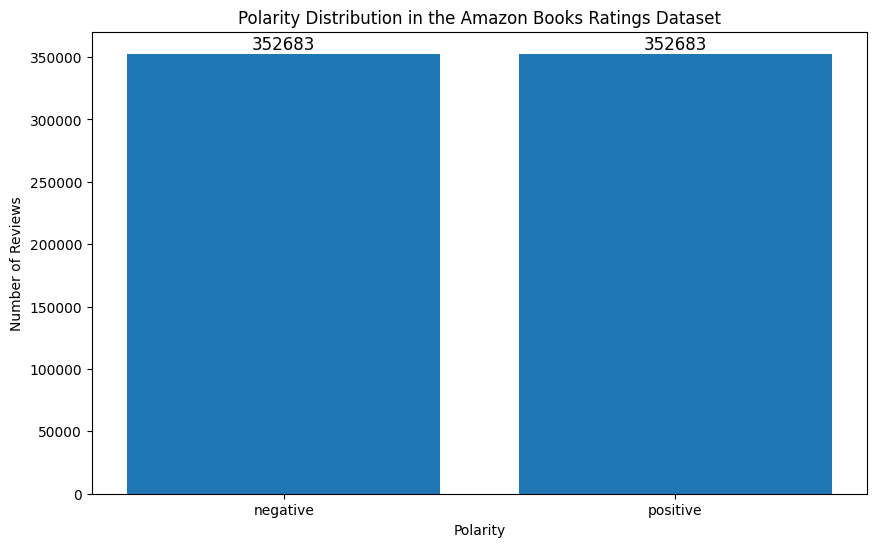

In [22]:
# plot the polarity distribution
DataHandler.plot_polarity_distribution_with_labels(amazon_balanced_df, 'Amazon Books Ratings')

In [23]:
# display the top 25 most frequent tokens
DataHandler.display_top_tokens(amazon_balanced_df, 'Review')

    Token   Count
0       !  151176
1     the   89962
2       ,   86131
3      of   79847
4       .   72921
5    book   70740
6       A   66208
7       a   64494
8     and   56100
9      to   45865
10    The   41631
11      I   41243
12    for   41122
13      ?   34331
14     is   33192
15    ...   31398
16     's   30570
17   this   29796
18     it   27894
19   read   25556
20    Not   24466
21     in   24229
22  Great   24029
23    n't   22960
24   Book   21616


## 3.2 Data Preprocessing - Sentiment140

In [24]:
# map numerical polarity values to labels ('negative' and 'positive')
sentiment140_df['Polarity'] = sentiment140_df['Polarity'].replace({0: 'negative', 4: 'positive'})

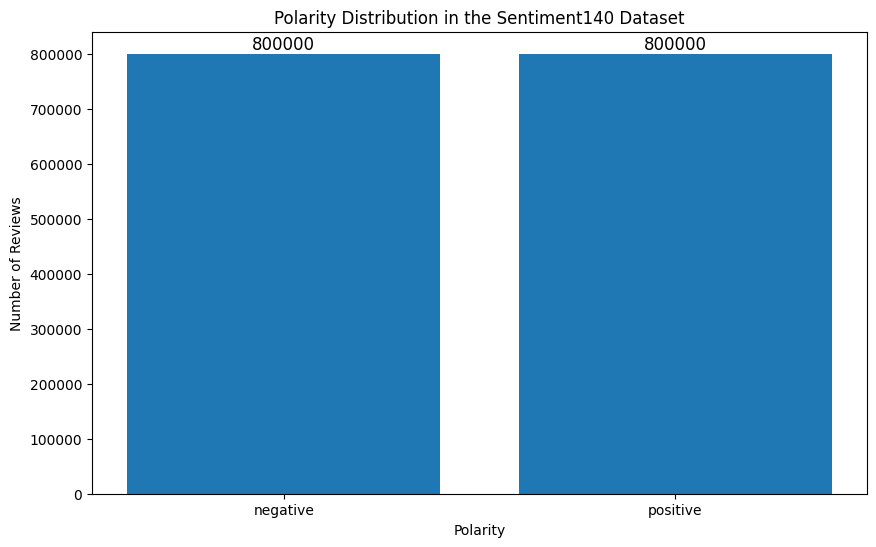

In [25]:
# plot the polarity distribution
DataHandler.plot_polarity_distribution_with_labels(sentiment140_df, 'Sentiment140')

In [26]:
# display the top 25 most frequent tokens
DataHandler.display_top_tokens(sentiment140_df, 'Review')  

   Token   Count
0      !  917950
1      .  804773
2      @  798682
3      I  652879
4     to  557549
5    the  490130
6      ,  484468
7      a  367729
8      i  299245
9     my  282842
10   and  281822
11   you  268826
12    it  260944
13     ?  247562
14    is  230283
15   ...  220073
16   for  211842
17    in  207194
18    of  180533
19    's  179216
20   n't  173581
21     ;  166822
22    on  160301
23    me  154979
24  that  147660


## 3.3 Data Preprocessing - Yelp Reviews

In [27]:
# map numerical polarity values to labels ('negative' and 'positive')
yelp_df['Polarity'] = yelp_df['Polarity'].replace({1: 'negative', 2: 'positive'})

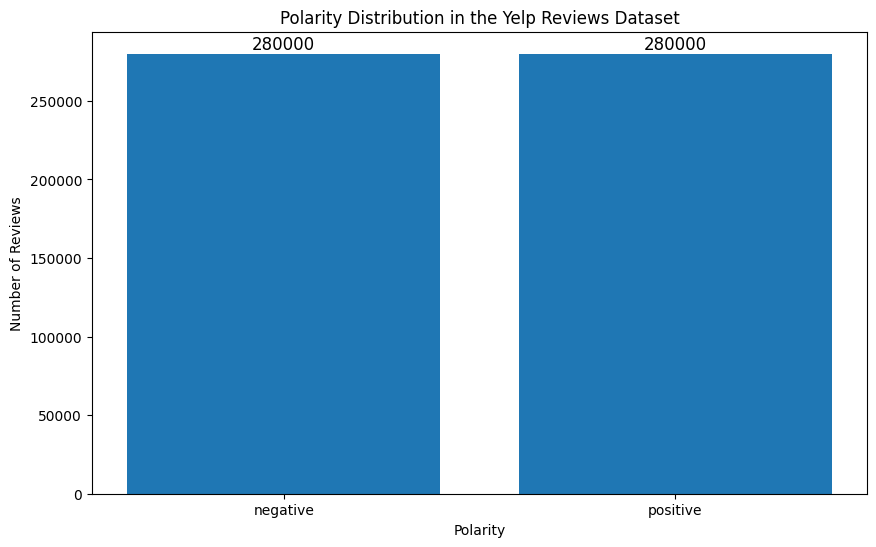

In [28]:
# plot the polarity distribution
DataHandler.plot_polarity_distribution_with_labels(yelp_df, 'Yelp Reviews')

In [29]:
# display the top 25 most frequent tokens
DataHandler.display_top_tokens(yelp_df, 'Review')  

   Token    Count
0      .  3977796
1    the  3169242
2      ,  2717635
3    and  2356227
4      I  2115246
5     to  1870691
6      a  1837871
7    was  1379177
8     of  1101404
9     it   928536
10    is   844433
11   for   837534
12    in   823774
13     !   790284
14  that   715968
15    my   566643
16  with   560569
17   you   549420
18   n't   539017
19   but   518953
20    on   512119
21   The   509584
22  this   475514
23  have   471896
24  they   458200


# 4. Save Data

In [30]:
# path to the folder where files will be saved (relative path)
output_dir = "../data/processed/"

# save the balanced Amazon dataset
amazon_balanced_df.to_csv(os.path.join(output_dir, "amazon_initial.csv"), index=False, encoding='utf-8')

# save the Sentiment140 dataset
sentiment140_df.to_csv(os.path.join(output_dir, "sentiment140_initial.csv"), index=False, encoding='utf-8')

# save the Yelp dataset
yelp_df.to_csv(os.path.join(output_dir, "yelp_initial.csv"), index=False, encoding='utf-8')

print("Datasets have been saved in the folder:", os.path.abspath(output_dir))

Datasets have been saved in the folder: d:\projects\sentiment-analysis\data\processed
